In [1]:
import numpy as np
import matplotlib.pyplot as plt

data_real = np.load("/shared/projects/phisat2/data/processed/triplets_v1/diagnostics/raw_histograms_real_images.npz")
data_sim = np.load("/shared/projects/phisat2/data/processed/triplets_v1/diagnostics/raw_histograms_sim_images.npz")

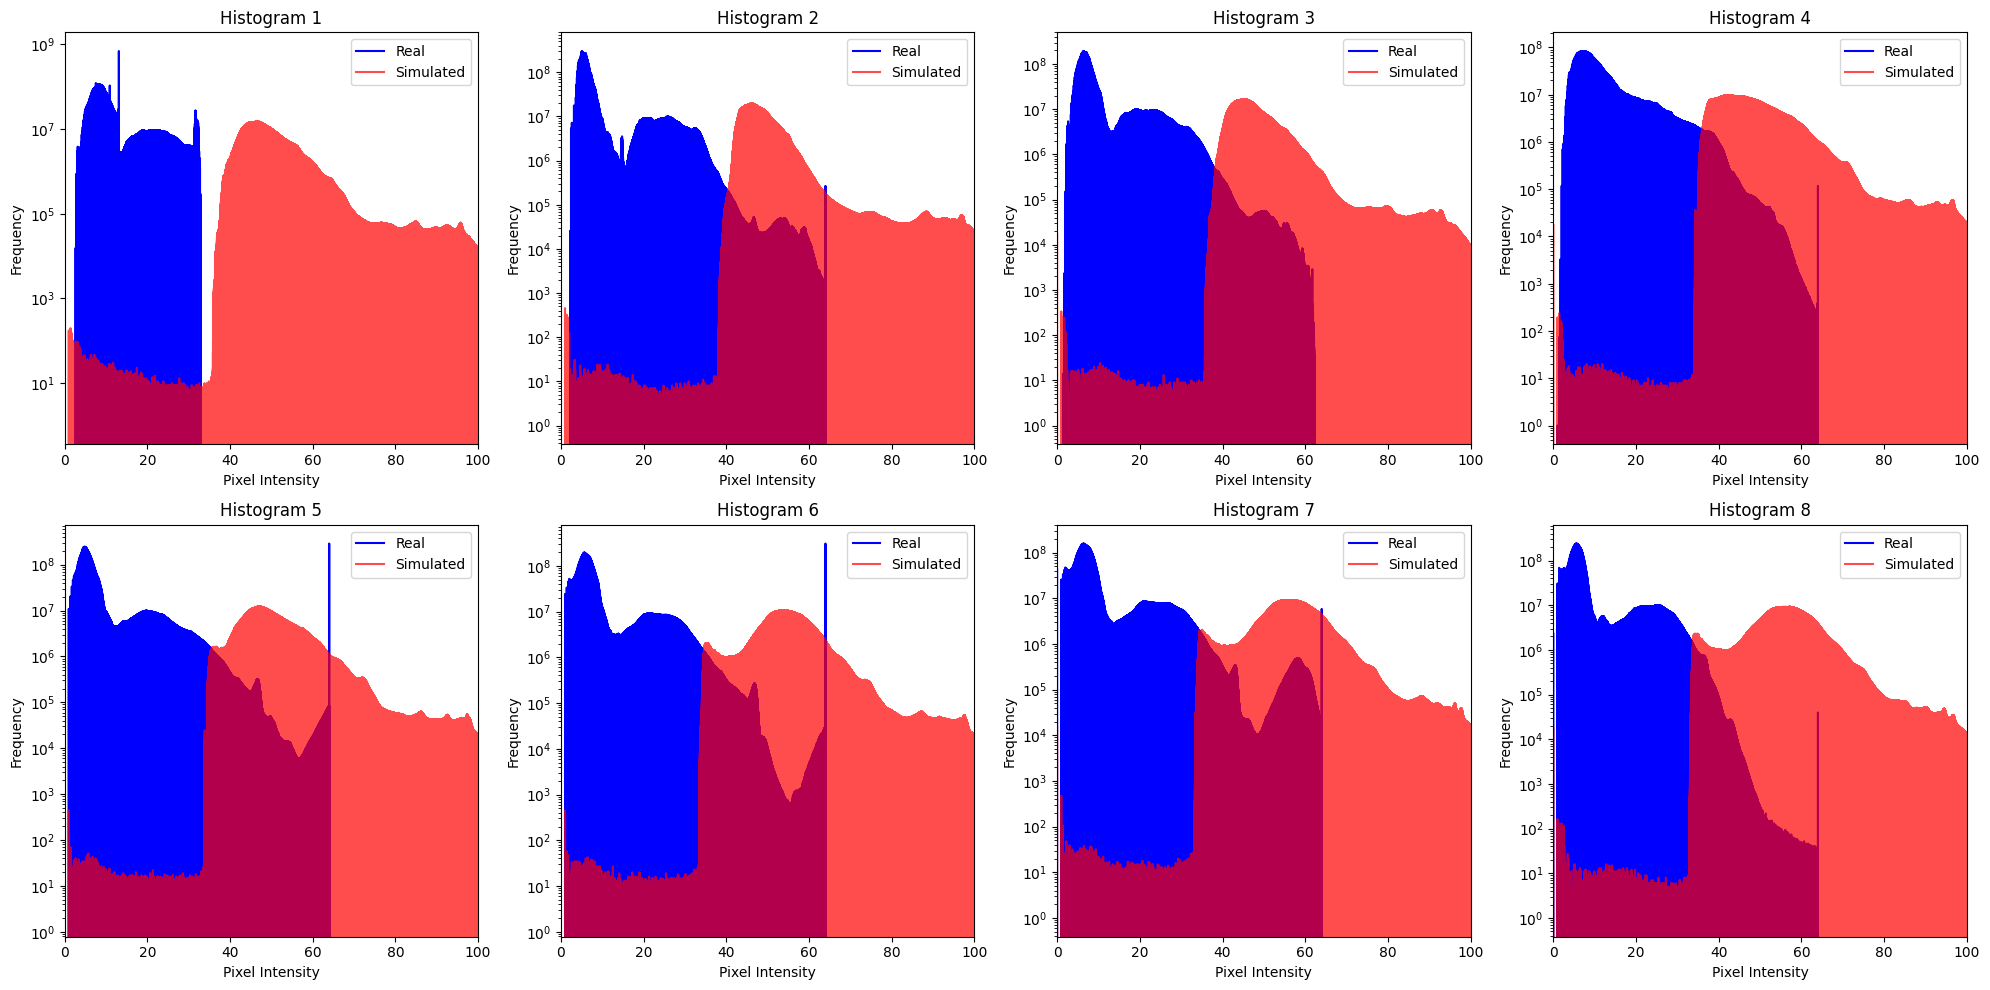

In [2]:
hist_real = data_real['hist_pre']
hist_sim = data_sim['hist_pre']
bin_edges = data_real['bins']
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i in range(8):
    ax = axes[i // 4, i % 4]
    ax.plot(bin_centers, hist_real[i], label='Real', color='blue')
    ax.plot(bin_centers, hist_sim[i], label='Simulated', color='red', alpha=0.7)
    ax.set_title(f'Histogram {i+1}')
    ax.set_xlabel('Pixel Intensity')
    ax.set_ylabel('Frequency')
    ax.set_xlim(0, 100)
    ax.legend()
    ax.set_yscale('log')
plt.tight_layout()
plt.show()

In [ ]:
hist_real = data_real['hist_pre']
hist_sim = data_sim['hist_post']
bins = data_real['bins']
bin_centers = (bins[:-1] + bins[1:]) / 2

lut_full = np.zeros((8, 30000), dtype=np.float32)
hrs = np.zeros((8, 30000), dtype=np.float32)
hss = np.zeros((8, 30000), dtype=np.float32)
for c in range(8):
    h_r = hist_real[c].astype(np.float64)
    h_s = hist_sim[c].astype(np.float64)
    
    cdf_real = np.cumsum(h_r) / np.sum(h_r)
    cdf_sim = np.cumsum(h_s) / np.sum(h_s)
    
    lut_full[c] = np.interp(cdf_real, cdf_sim, bin_centers)
    hrs[c] = h_r
    hss[c] = h_s

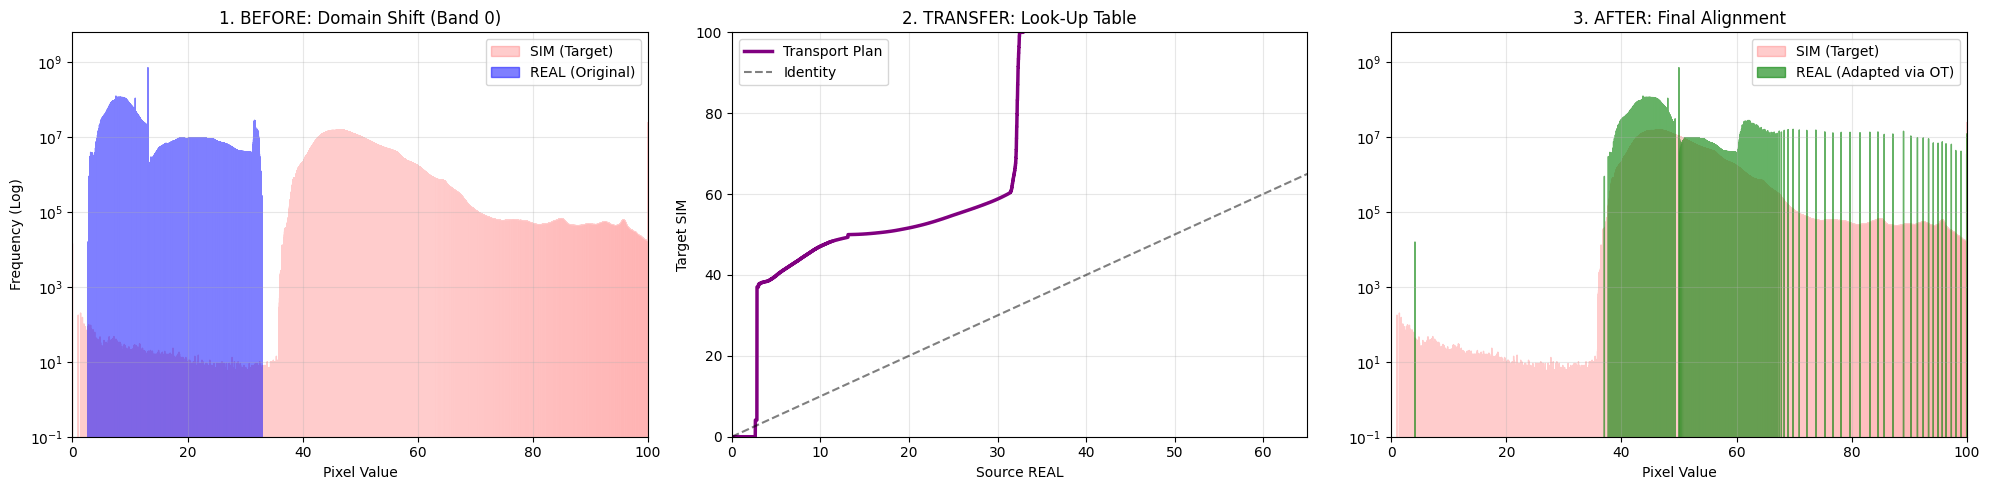

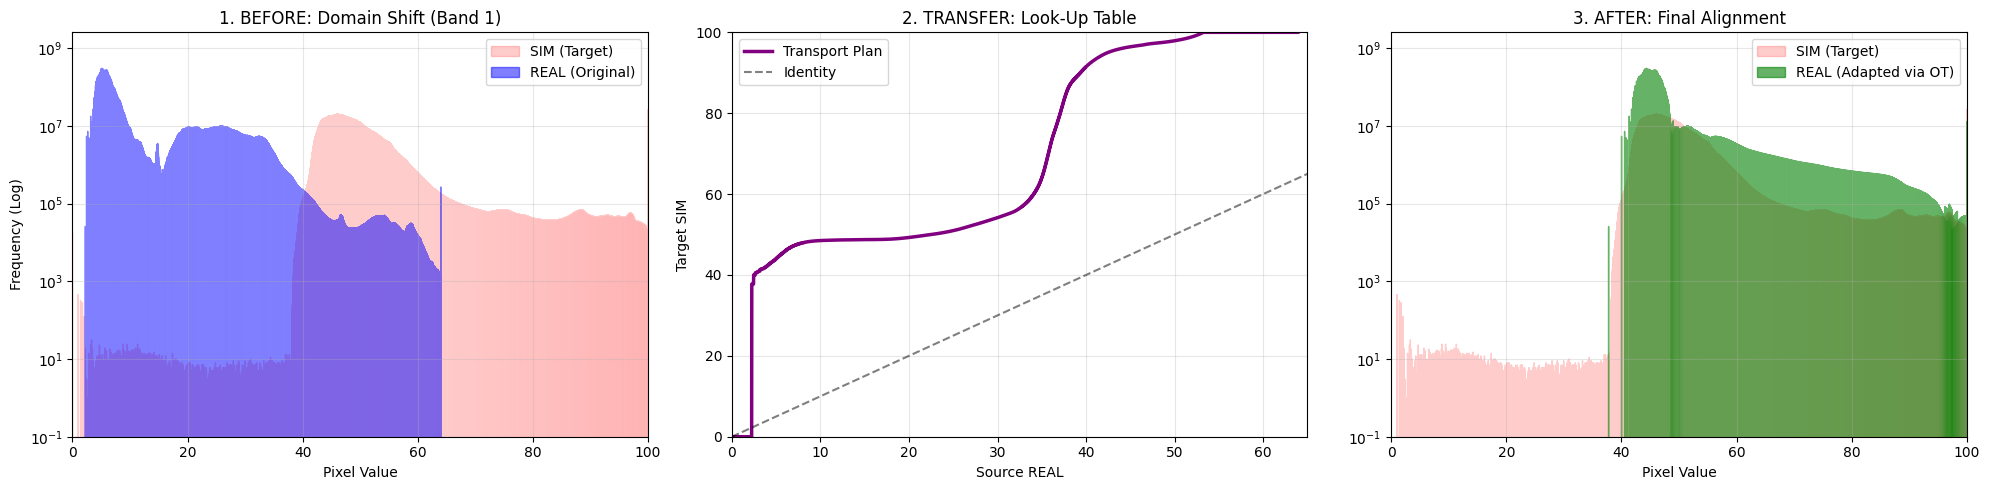

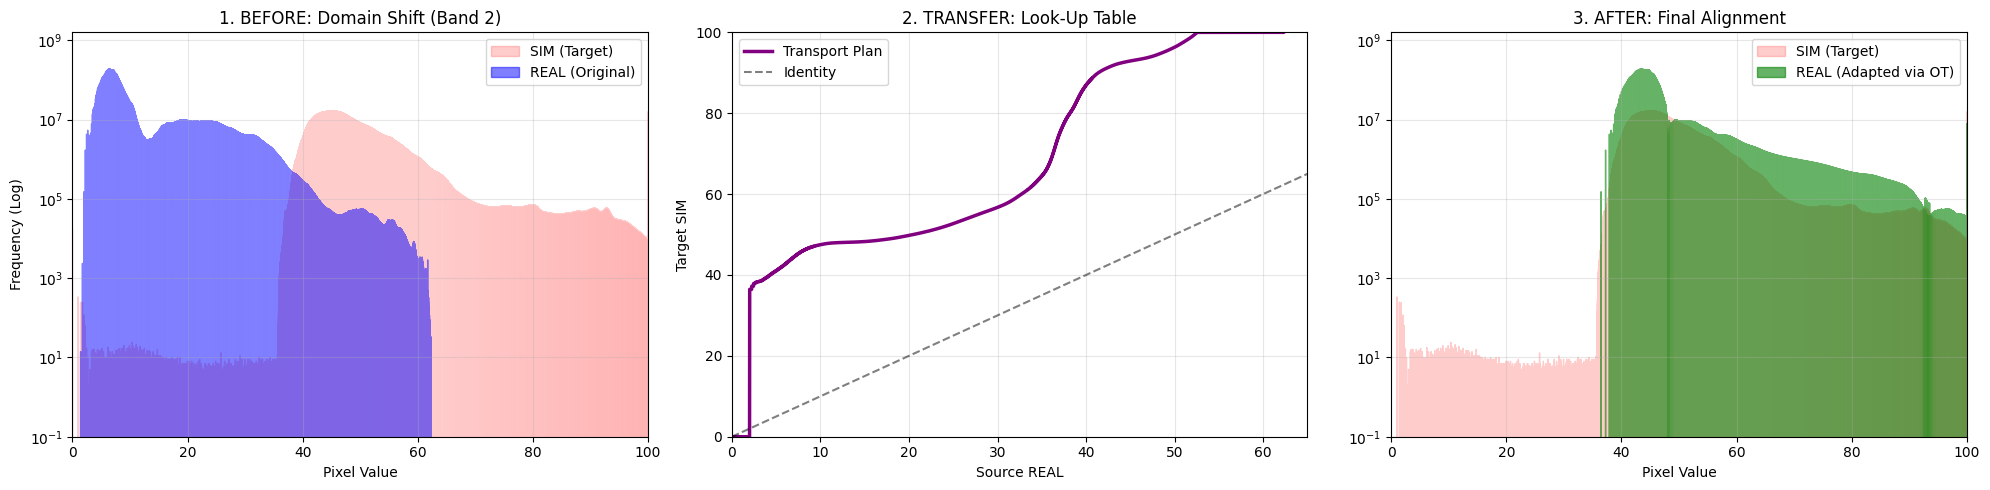

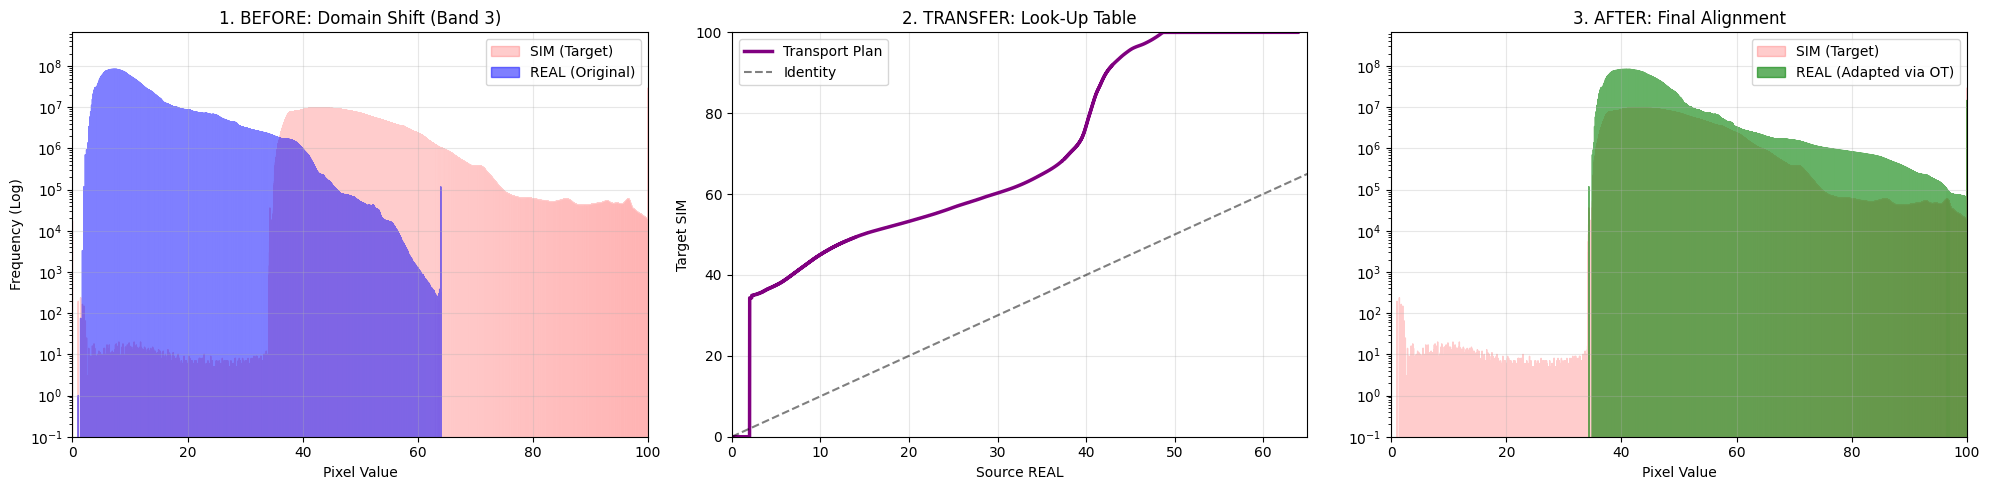

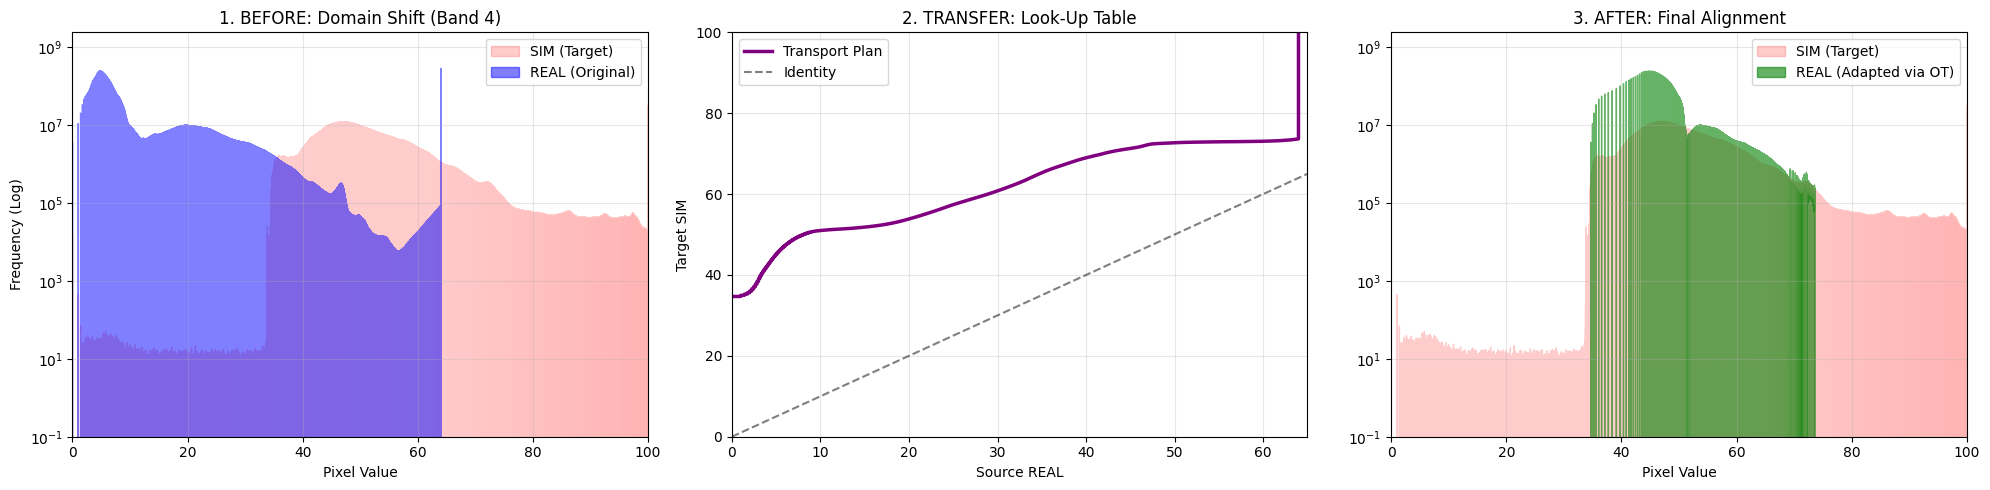

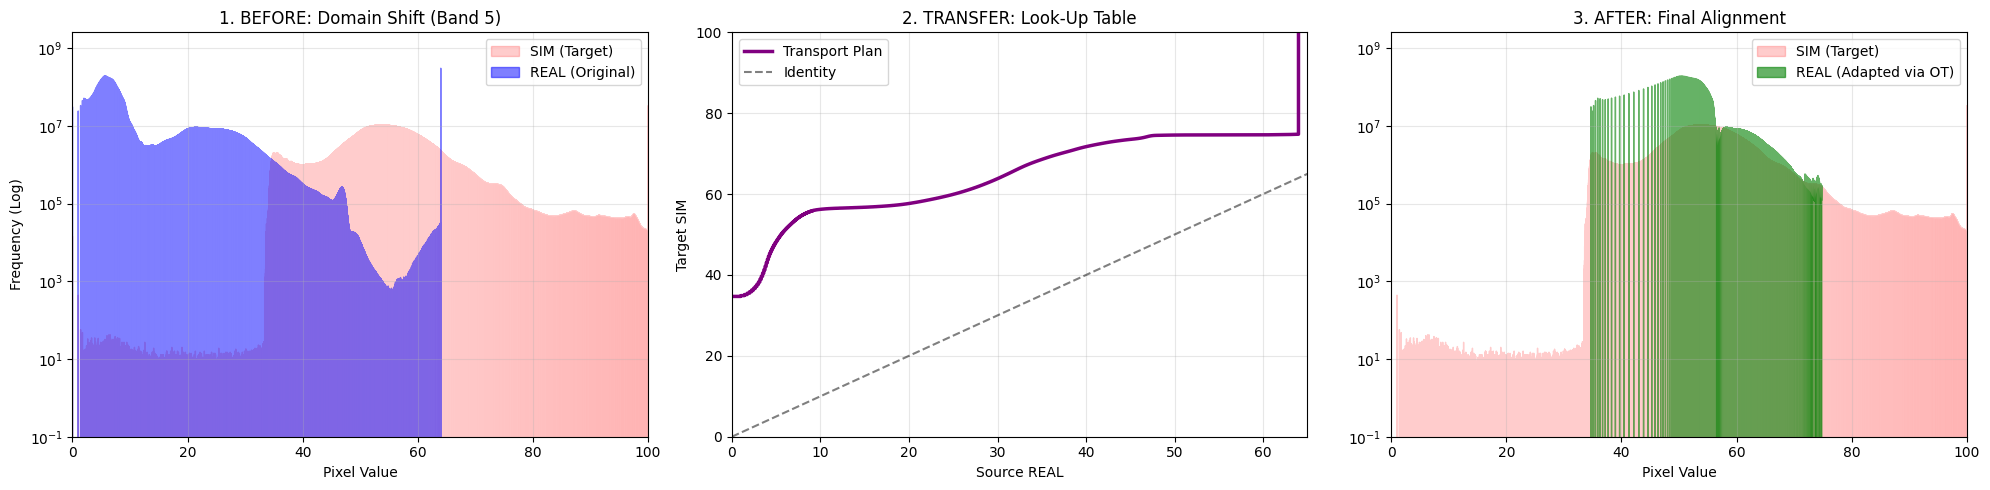

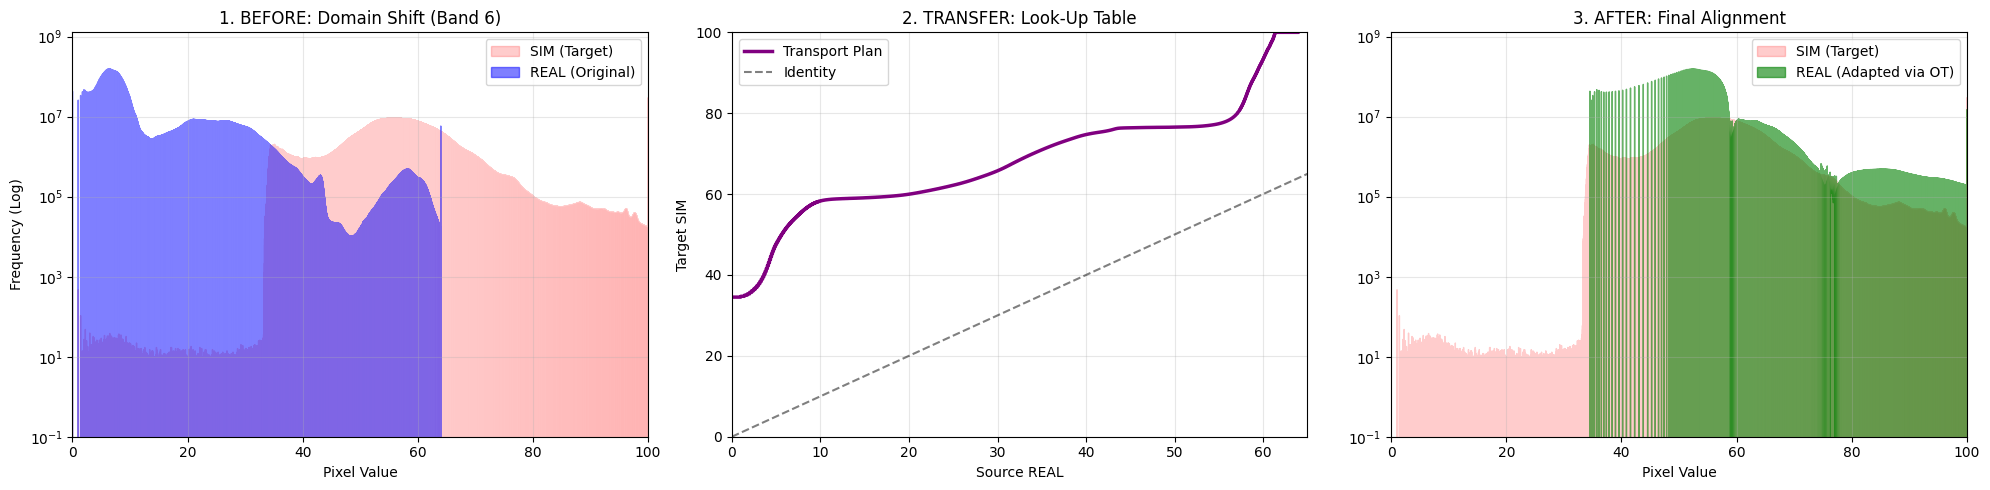

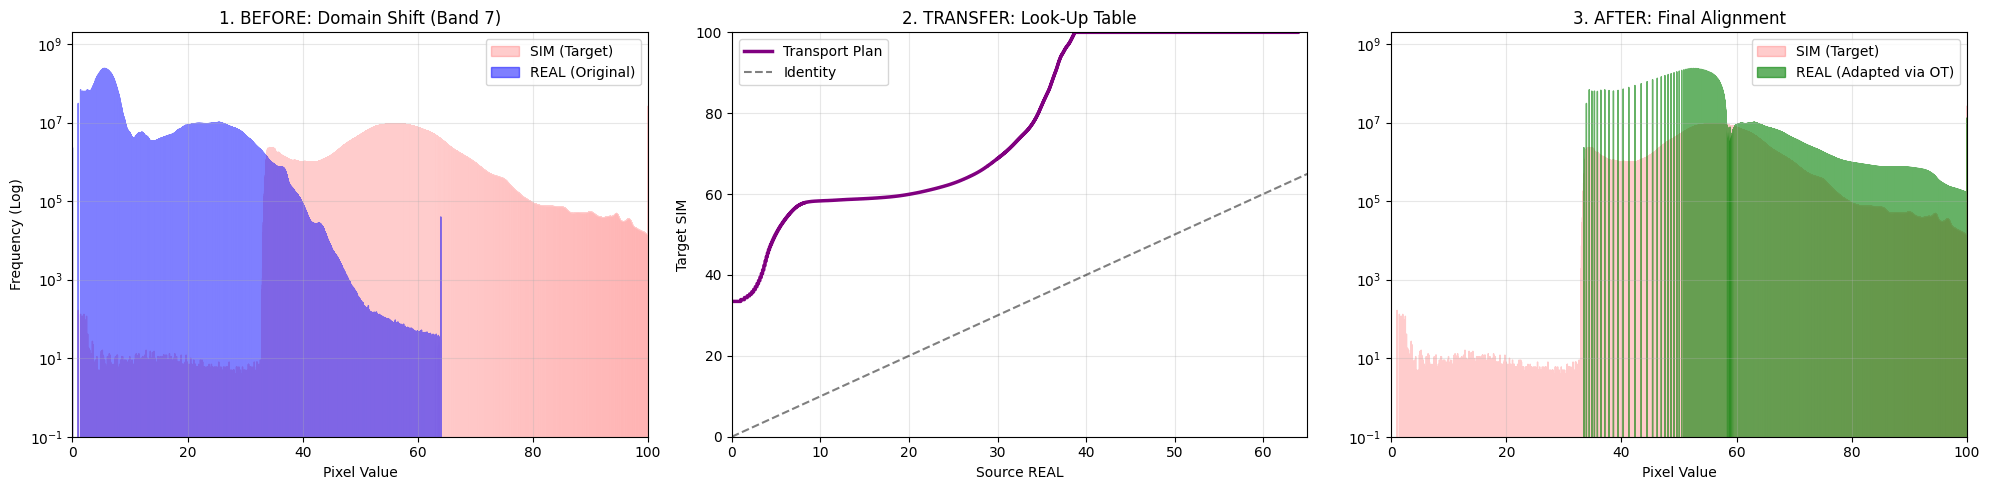

In [19]:
LIMIT_X_REAL = 65
LIMIT_X_SIM = 100

for band in range(8):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    p_adapted, _ = np.histogram(lut_full[band], bins=bins, weights=hrs[band])
    
    # ---------------------------------------------------------
    # COLUMN 1: BEFORE (Original vs Target)
    # ---------------------------------------------------------
    axes[0].fill_between(bin_centers, 1e-10, hss[band], color='red', alpha=0.2, label='SIM (Target)')
    axes[0].fill_between(bin_centers, 1e-10, hrs[band], color='blue', alpha=0.5, label='REAL (Original)')
    
    axes[0].set_title(f"1. BEFORE: Domain Shift (Band {band})")
    axes[0].set_xlabel("Pixel Value")
    axes[0].set_ylabel("Frequency (Log)")
    axes[0].set_yscale('log')
    axes[0].set_xlim(0, LIMIT_X_SIM)
    axes[0].set_ylim(bottom=1e-1)
    axes[0].legend(loc="upper right")
    axes[0].grid(True, alpha=0.3)

    # ---------------------------------------------------------
    # COLUMN 2: TRANSPORT PLAN (The LUT)
    # ---------------------------------------------------------
    axes[1].plot(bin_centers, lut_full[band], color='purple', linewidth=2.5, label='Transport Plan')
    axes[1].plot([0, LIMIT_X_SIM], [0, LIMIT_X_SIM], 'k--', alpha=0.5, label='Identity')
    
    axes[1].set_title("2. TRANSFER: Look-Up Table")
    axes[1].set_xlabel("Source REAL")
    axes[1].set_ylabel("Target SIM")
    axes[1].set_xlim(0, LIMIT_X_REAL)
    axes[1].set_ylim(0, LIMIT_X_SIM)
    axes[1].legend(loc="upper left")
    axes[1].grid(True, alpha=0.3)

    # ---------------------------------------------------------
    # COLUMN 3: AFTER (Adapted vs Target)
    # ---------------------------------------------------------
    axes[2].fill_between(bin_centers, 1e-10, hss[band], color='red', alpha=0.2, label='SIM (Target)')
    axes[2].fill_between(bin_centers, 1e-10, p_adapted, color='green', alpha=0.6, label='REAL (Adapted via OT)')
    
    axes[2].set_title("3. AFTER: Final Alignment")
    axes[2].set_xlabel("Pixel Value")
    axes[2].set_yscale('log')
    axes[2].set_xlim(0, LIMIT_X_SIM)
    axes[2].set_ylim(bottom=1e-1)
    axes[2].legend(loc="upper right")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

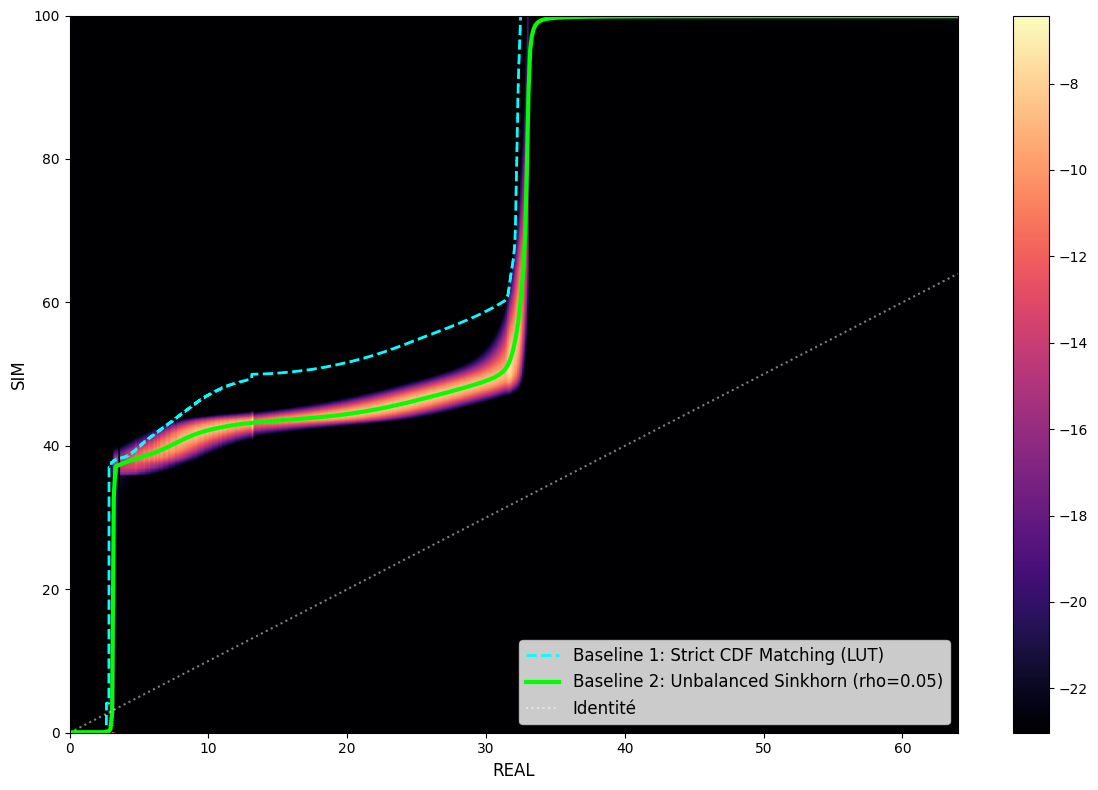

In [ ]:
path_lut_strict = "cache/ot_lut_seed_42.npy"

lut_strict_full = np.load(path_lut_strict)

band = 0
bins = data_real['bins']
bin_centers = (bins[:-1] + bins[1:]) / 2

FACTOR = 30
x_full = bin_centers.reshape(-1, FACTOR).mean(axis=1)

hist_r = data_real['hist_pre'][band].reshape(-1, FACTOR).sum(axis=1).astype(np.float64)
hist_s = data_sim['hist_post'][band].reshape(-1, FACTOR).sum(axis=1).astype(np.float64)

LIMIT_REAL = 64.0  
LIMIT_SIM  = 100.0 

mask_r = x_full <= LIMIT_REAL
mask_s = x_full <= LIMIT_SIM

x = x_full[mask_r]
y = x_full[mask_s]
n, m = len(x), len(y)

normalize = lambda p: p / np.sum(p)
a = normalize(hist_r[mask_r] + 1e-10)
b = normalize(hist_s[mask_s] + 1e-10)

C = np.abs(x[:,None] - y[None,:])**2
C = C / np.max(C)

def mina_u(H, epsilon): return -epsilon*np.log( np.sum(a[:,None] * np.exp(-H/epsilon),0) )
def minb_u(H, epsilon): return -epsilon*np.log( np.sum(b[None,:] * np.exp(-H/epsilon),1) )
def mina(H, epsilon): return mina_u(H-np.min(H,0),epsilon) + np.min(H,0)
def minb(H, epsilon): return minb_u(H-np.min(H,1)[:,None],epsilon) + np.min(H,1)

epsilon = 0.0001
rho = 0.05
kappa = rho / (rho + epsilon)
niter = 500

f = np.zeros(n)
for it in range(niter):
    g = kappa * mina(C - f[:,None], epsilon)
    f = kappa * minb(C - g[None,:], epsilon)

P = a[:,None] * np.exp((f[:,None] + g[None,:] - C) / epsilon) * b[None,:]

gamma_sum = np.sum(P, axis=1)
mask_valid = gamma_sum > 1e-30

x_valid = x[mask_valid]
barycenter_valid = np.sum(P[mask_valid, :] * y[None, :], axis=1) / gamma_sum[mask_valid]

x_interp = np.concatenate(([0.0], x_valid, [LIMIT_REAL]))
y_interp = np.concatenate(([0.0], barycenter_valid, [LIMIT_SIM]))

lut_unbalanced = np.interp(x, x_interp, y_interp)
lut_unbalanced = np.maximum.accumulate(lut_unbalanced)

fig, ax = plt.subplots(figsize=(12, 8))

def remap_plan(P): return np.log(1e-10 + P)
im = ax.imshow(remap_plan(P.T), origin='lower', 
               extent=[0, LIMIT_REAL, 0, LIMIT_SIM], 
               cmap='magma', aspect='auto')

ax.plot(bin_centers, lut_strict_full[band], color='cyan', linewidth=2, linestyle='--', 
        label='Baseline 1: Strict CDF Matching (LUT)')

ax.plot(x, lut_unbalanced, color='lime', linewidth=3, 
        label=f'Baseline 2: Unbalanced Sinkhorn (rho={rho})')

ax.plot([0, min(LIMIT_REAL, LIMIT_SIM)], [0, min(LIMIT_REAL, LIMIT_SIM)], 'w:', alpha=0.5, label='Identity')

ax.set_xlabel("REAL", fontsize=12)
ax.set_ylabel("SIM", fontsize=12)
ax.set_xlim(0, LIMIT_REAL)
ax.set_ylim(0, LIMIT_SIM)
ax.legend(fontsize=12, loc='lower right')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [ ]:
lut_unbalanced_full = np.zeros((8, len(bin_centers)), dtype=np.float32)

for c in range(8):
    a = normalize(data_real['hist_pre'][c].reshape(-1, FACTOR).sum(axis=1)[mask_r].astype(np.float64) + 1e-10)
    b = normalize(data_sim['hist_post'][c].reshape(-1, FACTOR).sum(axis=1)[mask_s].astype(np.float64) + 1e-10)
    
    f = np.zeros(n)
    for it in range(niter):
        g = kappa * mina(C - f[:,None], epsilon)
        f = kappa * minb(C - g[None,:], epsilon)
    P = a[:,None] * np.exp((f[:,None] + g[None,:] - C) / epsilon) * b[None,:]
    
    gamma_sum = np.sum(P, axis=1)
    mask_valid = gamma_sum > 1e-30 
    
    x_valid = x[mask_valid]
    barycenter_valid = np.sum(P[mask_valid, :] * y[None, :], axis=1) / gamma_sum[mask_valid]
    
    x_interp = np.concatenate(([0.0], x_valid, [LIMIT_REAL]))
    y_interp = np.concatenate(([0.0], barycenter_valid, [LIMIT_SIM]))
    
    lut_small = np.interp(x, x_interp, y_interp)
    lut_small = np.maximum.accumulate(lut_small)
    
    lut_unbalanced_full[c] = np.interp(bin_centers, x, lut_small)

#np.save(f"cache/ot_unbalanced_rho{rho}.npy", lut_unbalanced_full)

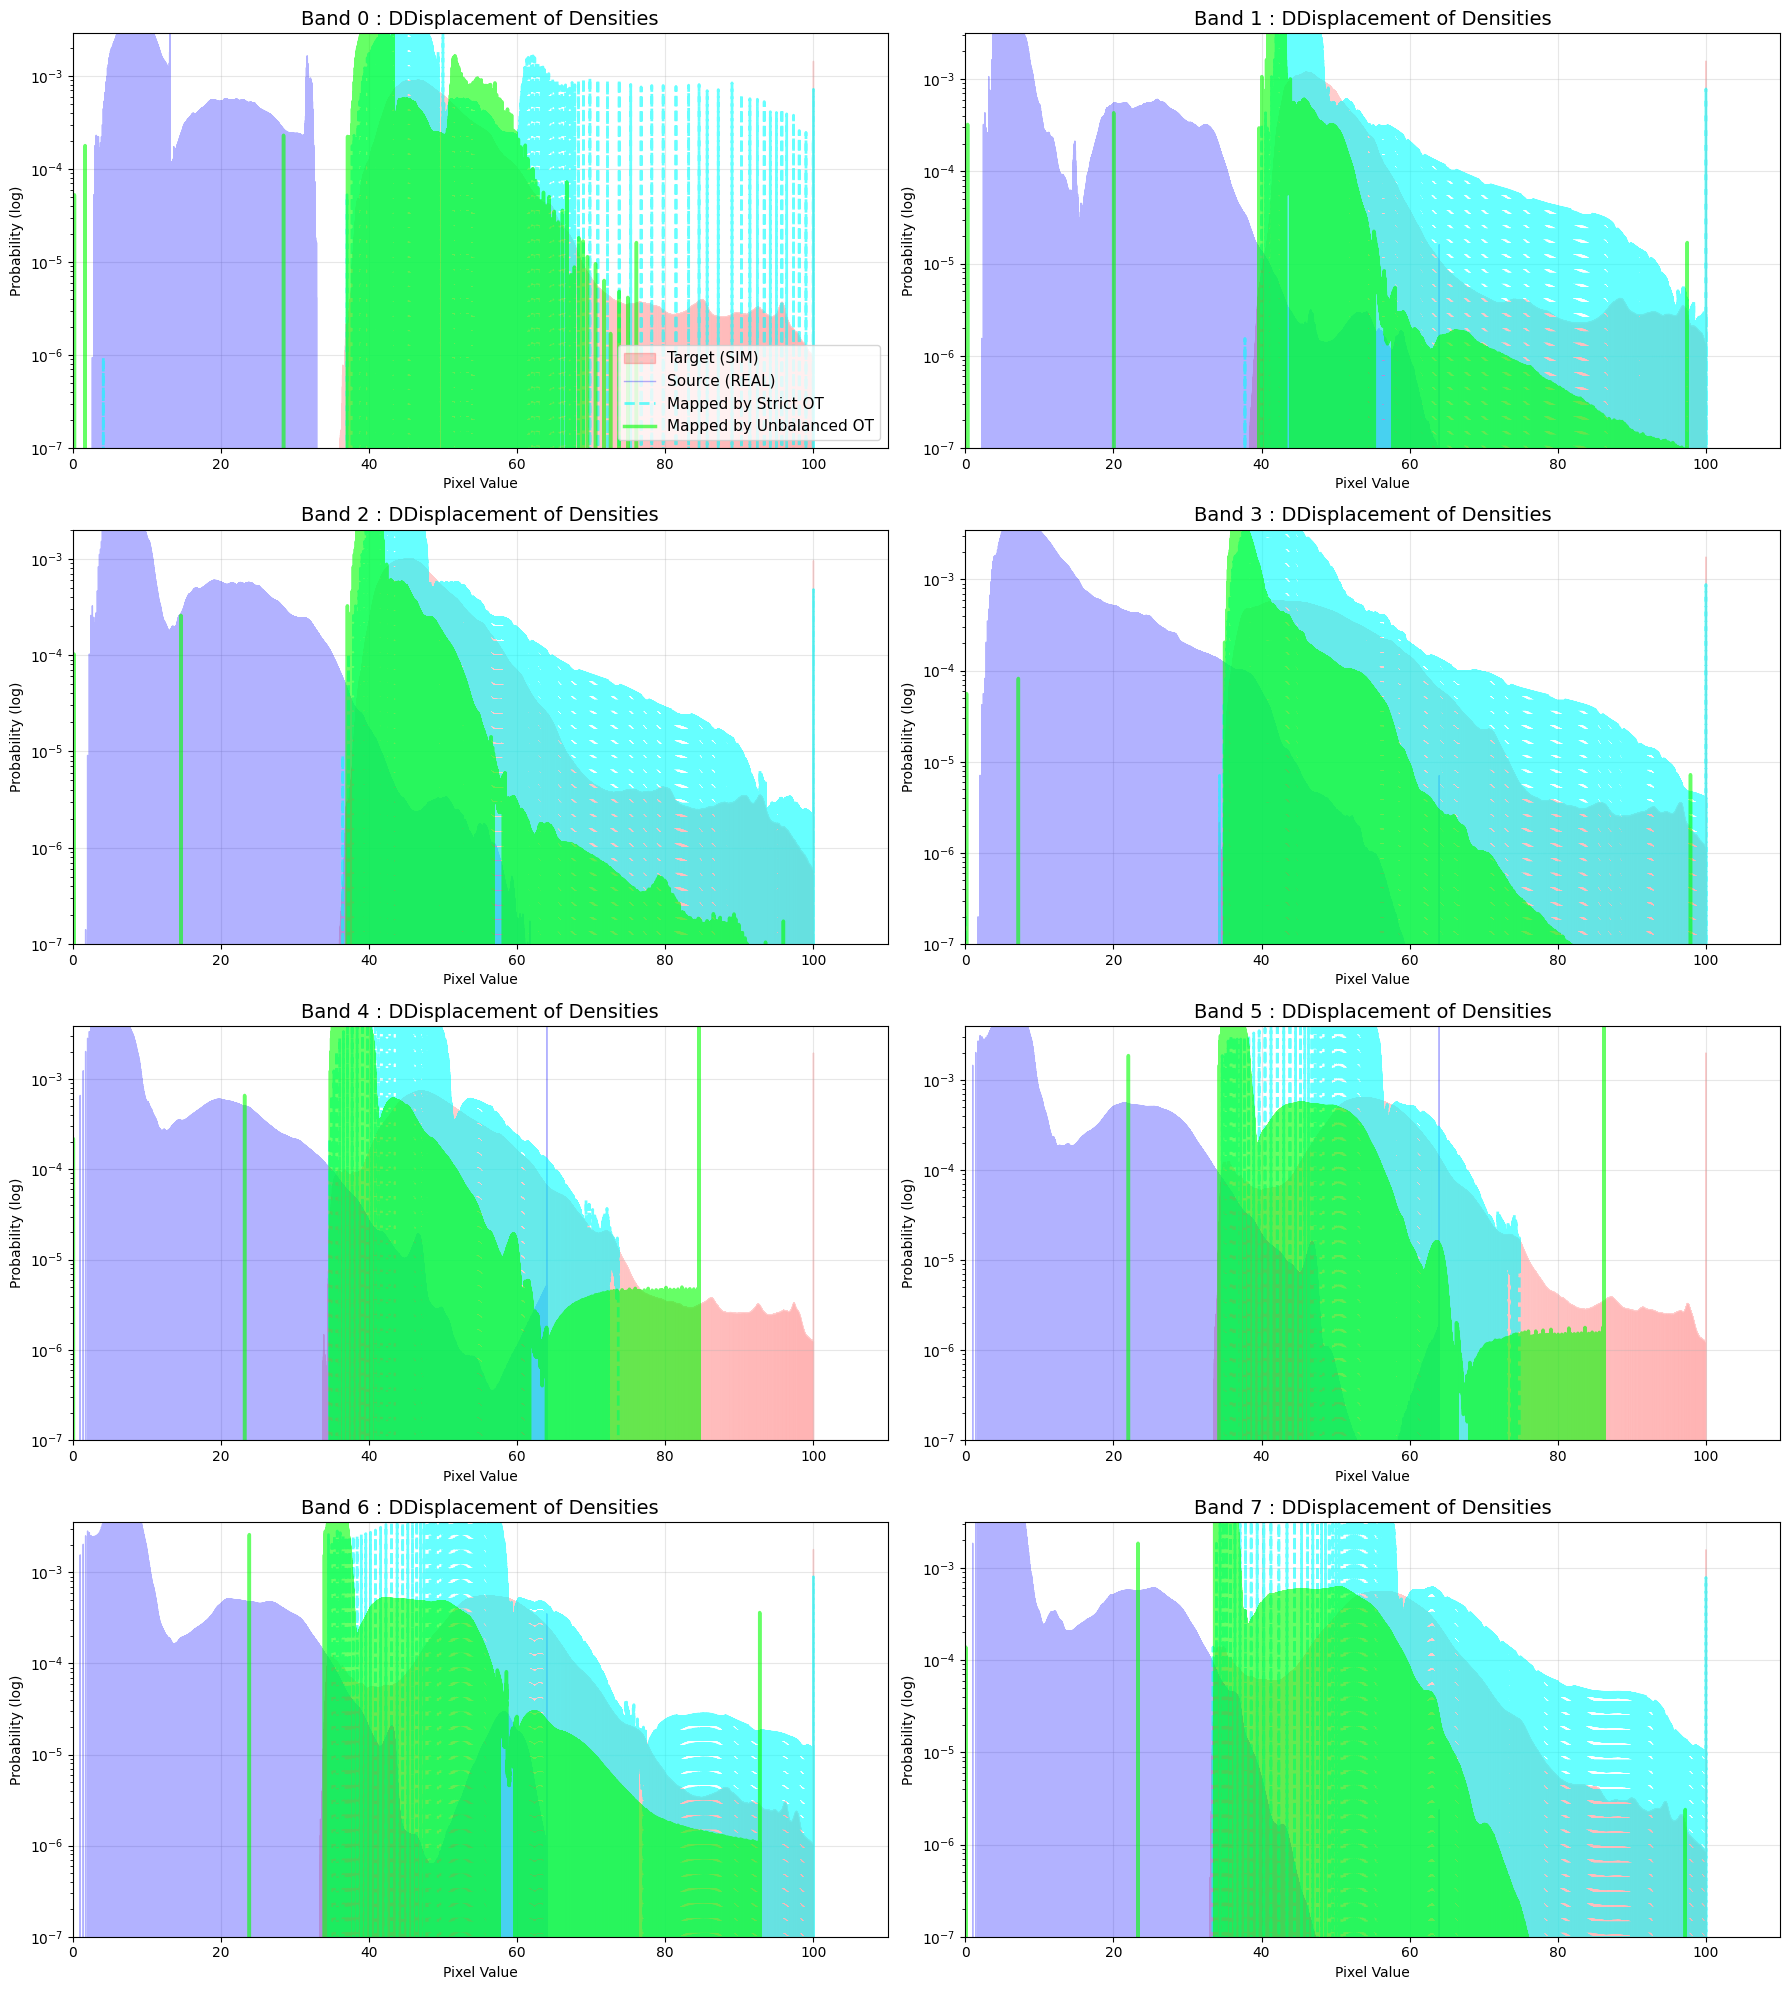

In [13]:
path_lut_strict = "cache/ot_lut_seed_42.npy"
path_lut_uot    = "cache/ot_unbalanced_rho0.05.npy"

lut_strict = np.load(path_lut_strict)
lut_uot    = np.load(path_lut_uot)

bins = data_real['bins']
bin_centers = (bins[:-1] + bins[1:]) / 2

hist_real = data_real['hist_pre']
hist_sim  = data_sim['hist_post']

fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.flatten()

LIMIT_X = 110 

for c in range(8):
    p_r = hist_real[c] / np.sum(hist_real[c])
    p_s = hist_sim[c] / np.sum(hist_sim[c])
    
    p_mapped_strict, _ = np.histogram(lut_strict[c], bins=bins, weights=p_r)
    p_mapped_uot, _    = np.histogram(lut_uot[c], bins=bins, weights=p_r)
    
    ax = axes[c]
    
    valid = bin_centers <= LIMIT_X
    x_plot = bin_centers[valid]
    
    ax.fill_between(x_plot, 1e-12, p_s[valid], color='red', alpha=0.2, label='Target (SIM)')
    
    ax.plot(x_plot, p_r[valid], color='blue', alpha=0.3, linewidth=1, label='Source (REAL)')
    
    ax.plot(x_plot, p_mapped_strict[valid], color='cyan', linestyle='--', linewidth=2, label='Mapped by Strict OT', alpha=0.6)
    ax.plot(x_plot, p_mapped_uot[valid], color='lime', linestyle='-', linewidth=2.5, label='Mapped by Unbalanced OT', alpha=0.6)
    
    ax.set_title(f"Band {c} : DDisplacement of Densities", fontsize=14)
    ax.set_xlabel("Pixel Value", fontsize=10)
    ax.set_ylabel("Probability (log)", fontsize=10)
    ax.set_yscale('log')
    ax.set_xlim(0, LIMIT_X)
    
    ax.set_ylim(1e-7, np.max(p_s)*2) 
    ax.grid(True, alpha=0.3)
    
    if c == 0:
        ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

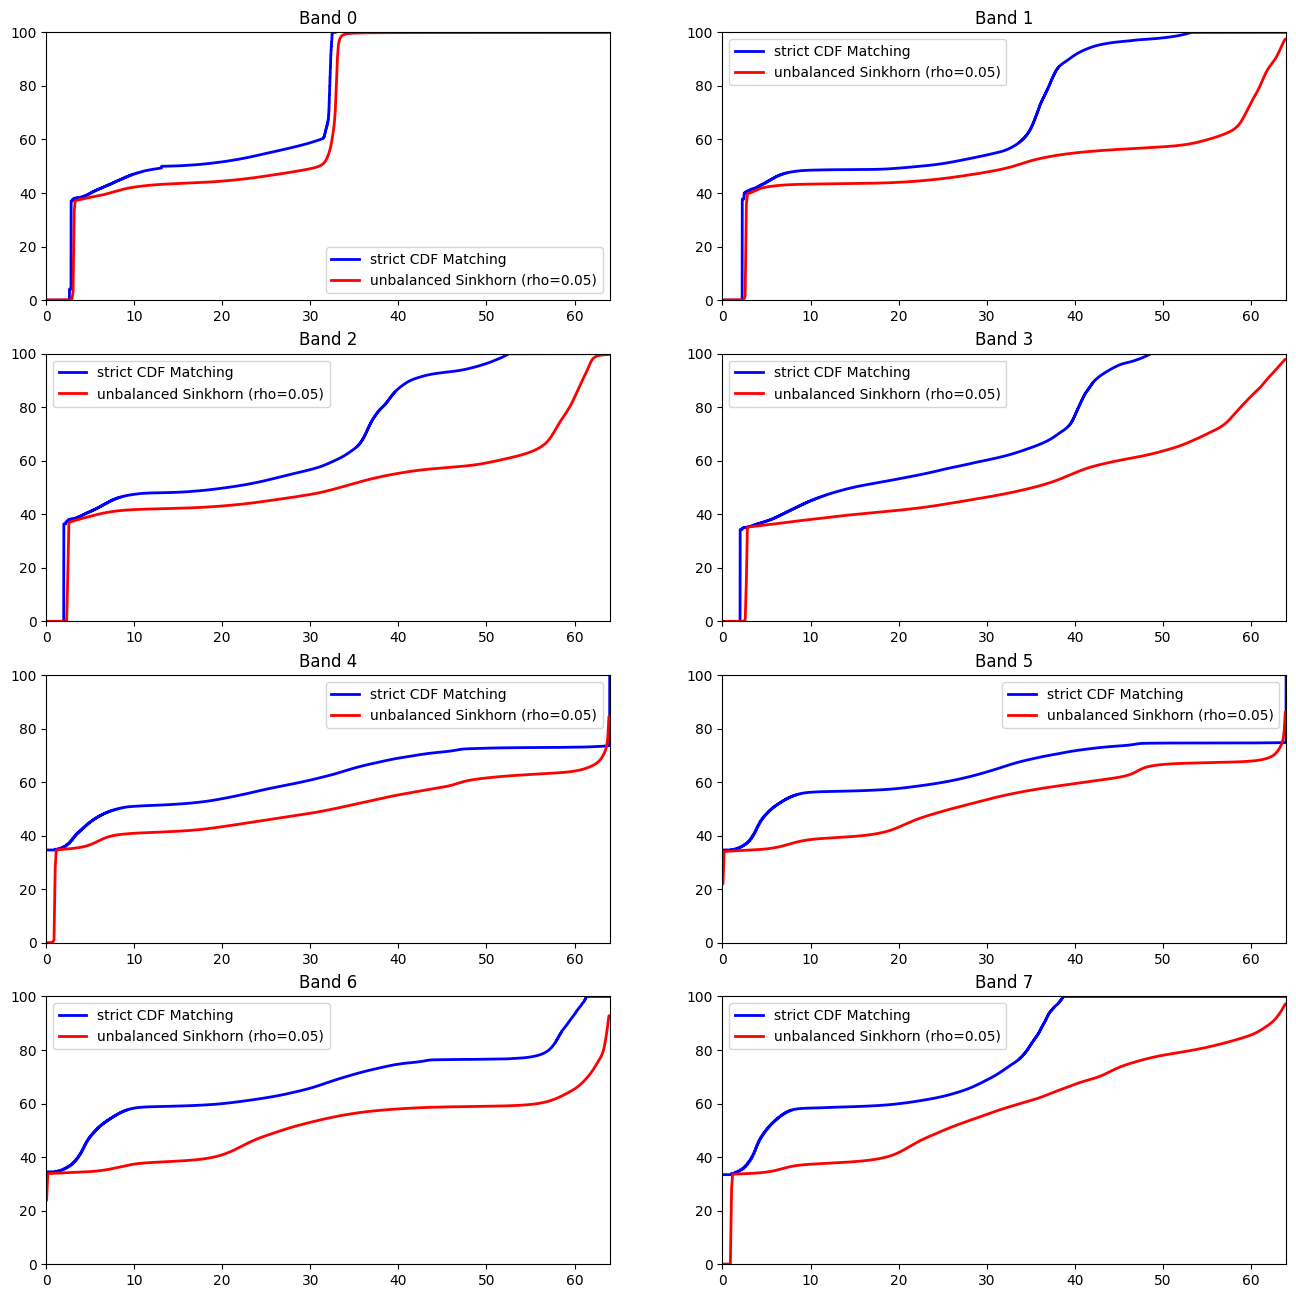

In [14]:
fig, axes = plt.subplots(4, 2, figsize=(16, 16))

for band in range(8):
        ax = axes[band // 2, band % 2]
        ax.plot(bin_centers, lut_strict[band], color='blue', linewidth=2, linestyle='-', 
                label='strict CDF Matching')
        ax.plot(bin_centers, lut_uot[band], color='red', linewidth=2, linestyle='-', 
        label=f'unbalanced Sinkhorn (rho={rho})')
        ax.legend()
        ax.set_title(f"Band {band}")
        ax.set_xlim(0, 64)
        ax.set_ylim(0, 100)